# About Dataset

Dream Housing Finance company deals in all home loans. They have presence across all urban, semi urban and rural areas. Customer first apply for home loan after that company validates the customer eligibility for loan.

Problem
Company wants to automate the loan eligibility process (real time) based on customer detail provided while filling online application form. These details are Gender, Marital Status, Education, Number of Dependents, Income, Loan Amount, Credit History and others. To automate this process, they have given a problem to identify the customers segments, those are eligible for loan amount so that they can specifically target these customers. Here they have provided a partial data set.

# Importing important libraries and dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from scipy import stats
from scipy.stats import pearsonr
from scipy.stats import ttest_ind
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [2]:
df = pd.read_csv("/content/loan_data_set.csv")

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(614, 13)

In [5]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [6]:
df = df.drop("Loan_ID", axis=1)

# EDA

In [7]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n")
    print(df[col].value_counts(dropna=False))



Gender
Male      489
Female    112
NaN        13
Name: count, dtype: int64


Married
Yes    398
No     213
NaN      3
Name: count, dtype: int64


Dependents
0      345
1      102
2      101
3+      51
NaN     15
Name: count, dtype: int64


Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64


Self_Employed
No     500
Yes     82
NaN     32
Name: count, dtype: int64


Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64


Loan_Status
Y    422
N    192
Name: count, dtype: int64


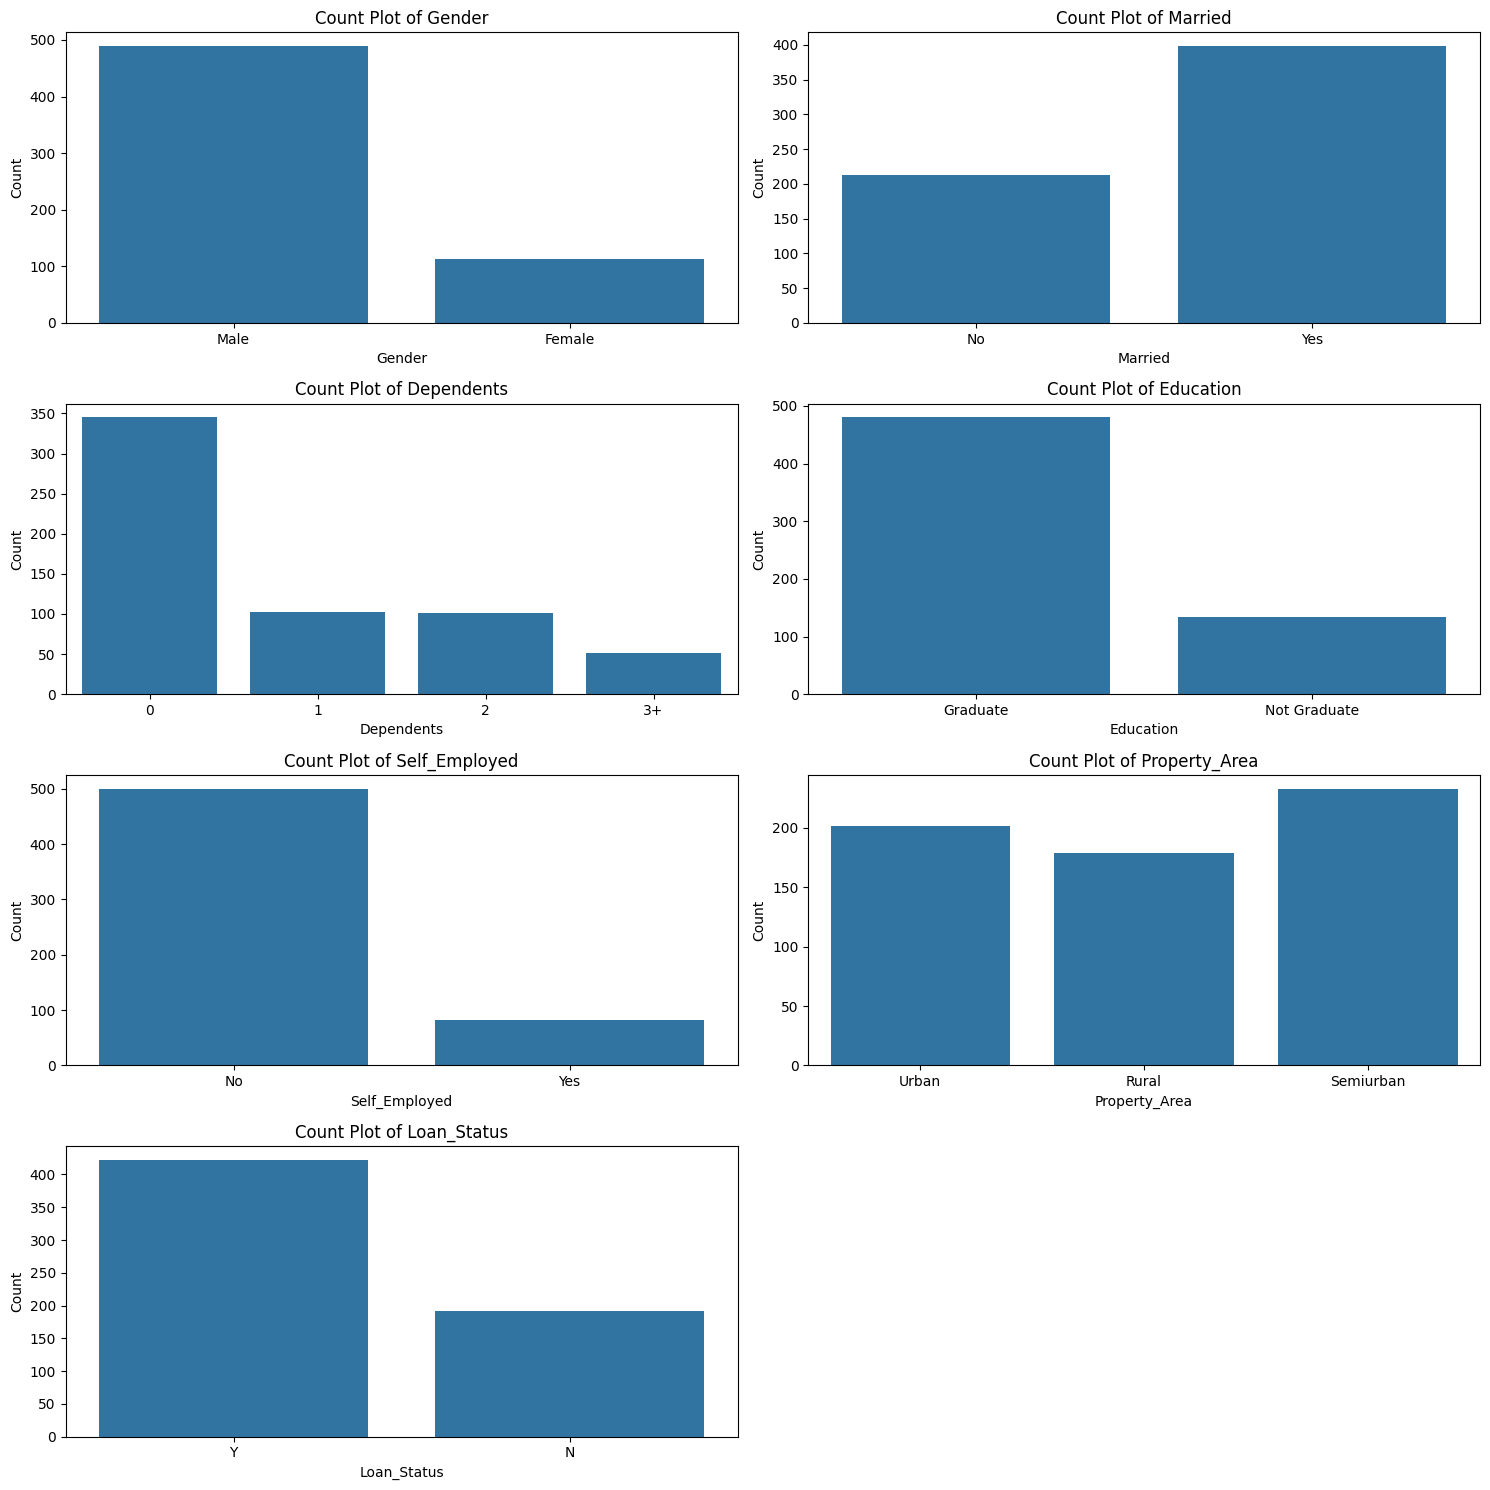

In [8]:
fig = plt.figure(figsize=(15, 15))
for i, col in enumerate(categorical_columns, 1):
    plt.subplot(4, 2, i)

    sns.countplot(
        data=df,
        x=col
    )

    plt.title(f"Count Plot of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")

plt.tight_layout()
plt.show()

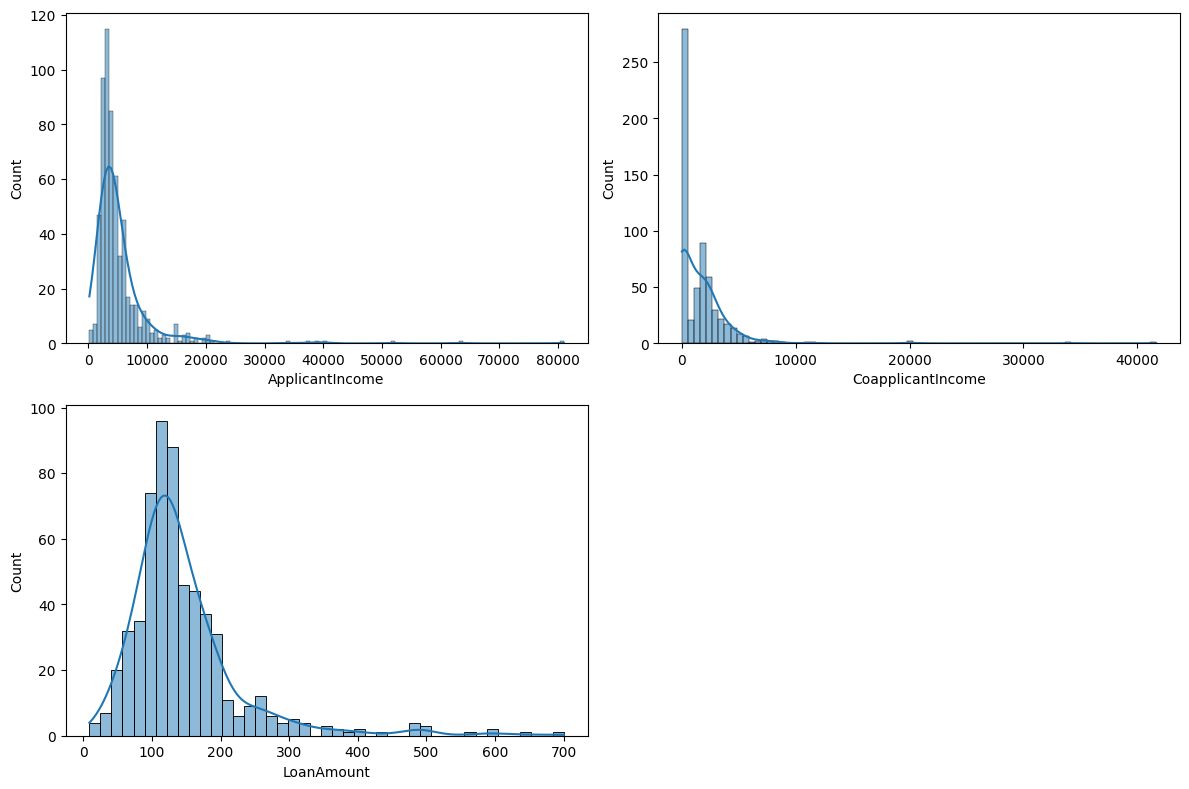

In [9]:
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.histplot(data=df, x="ApplicantIncome", kde=True)

plt.subplot(2, 2, 2)
sns.histplot(data=df, x="CoapplicantIncome", kde=True)

plt.subplot(2, 2, 3)
sns.histplot(data=df, x="LoanAmount", kde=True)

plt.tight_layout()
plt.show()

<Axes: >

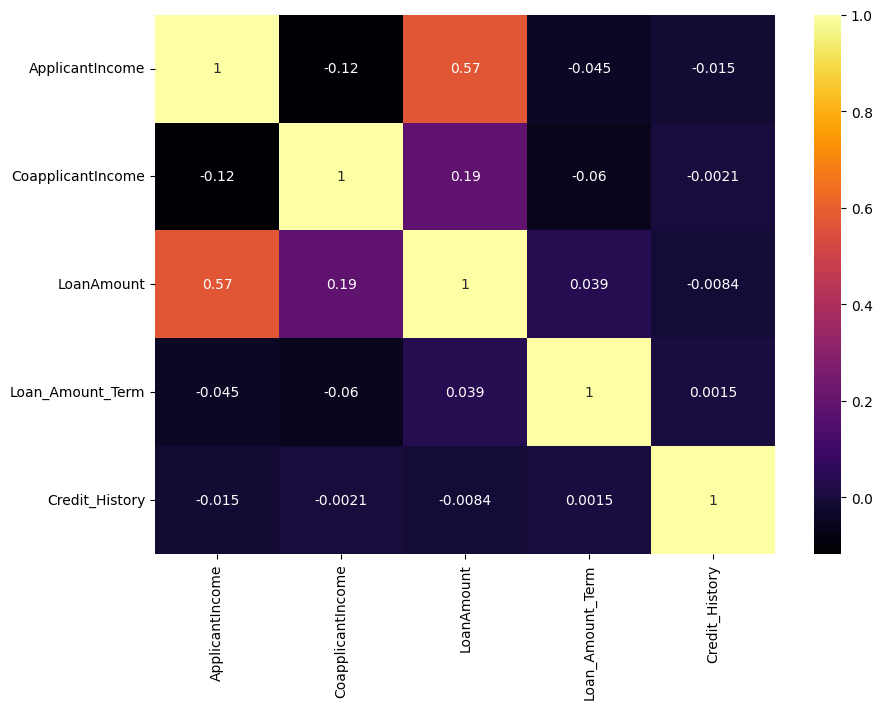

In [10]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='inferno')

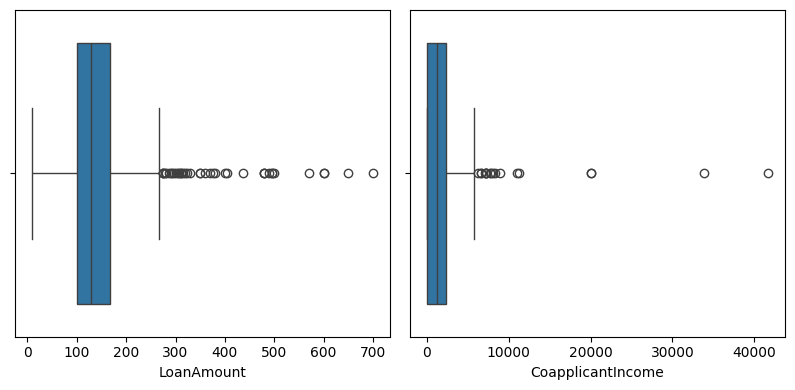

In [11]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sns.boxplot(data=df,x="LoanAmount")
plt.subplot(1,3,2)
sns.boxplot(data=df,x="CoapplicantIncome")
plt.tight_layout()
plt.show()

In [12]:
df=df.drop(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area'],axis=1)

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ApplicantIncome    614 non-null    int64  
 1   CoapplicantIncome  614 non-null    float64
 2   LoanAmount         592 non-null    float64
 3   Loan_Amount_Term   600 non-null    float64
 4   Credit_History     564 non-null    float64
 5   Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 28.9+ KB


In [14]:
df.isnull().sum()

,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14
Credit_History,50
Loan_Status,0


In [15]:
X = df[['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']]
y = df["Loan_Status"]

In [16]:
y.head()

,Loan_Status
0,Y
1,N
2,Y
3,Y
4,Y


In [17]:
y = y.map({"Y": 1, "N": 0})

In [18]:
X = X.fillna(X.mean())

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

# Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [25]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(confusion_matrix(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.8292682926829268

[[14 19]
 [ 2 88]]

              precision    recall  f1-score   support

           0       0.88      0.42      0.57        33
           1       0.82      0.98      0.89        90

    accuracy                           0.83       123
   macro avg       0.85      0.70      0.73       123
weighted avg       0.84      0.83      0.81       123



# Conclusion

The Logistic Regression model achieved an accuracy of approximately 82.93% on the test dataset. The model performed very well in identifying loan-approved applicants (Y), with a recall of approximately 98%. However, its recall for loan-rejected applicants (N) was only 42%, indicating that the model incorrectly classified a considerable number of rejected applications as approved.